# lora fine-tuning

this notebook fine-tunes a GPT-2 model using low-rank adaptation (LoRA)

In [1]:
# import standard-library tools for paths, data, timing, and reproducibility

import json
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

# import the libraries used for data, tensors, plotting, and LoRA

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import peft
import torch
import transformers

from datasets import Dataset, DatasetDict
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments

/Users/nabigchaudhry/Projects/build-llm-from-scratch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# record the library versions used for this experiment

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)

torch: 2.5.1
transformers: 5.17.0
datasets: 5.0.1
peft: 0.21.0


In [5]:
# keep experiment settings together so they are easy to compare later

seed = 123
model_name = "openai-community/gpt2"
max_length = 512
max_new_tokens = 64

# choose conservative settings for a small instruction dataset and MPS training

num_train_epochs = 5
train_batch_size = 4
eval_batch_size = 4
gradient_accumulation_steps = 4
learning_rate = 2e-4
weight_decay = 0.01
warmup_ratio = 0.1

# define the LoRA adapter capacity and regularization

lora_rank = 16
lora_alpha = 16
lora_dropout = 0.05

In [6]:
# seed the random-number generators before shuffling data or training

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# prefer MPS on an Apple Silicon mac and otherwise use CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


In [7]:
# support running the notebook from either the notebooks folder or the project root

notebook_folder = Path.cwd()

if not (notebook_folder / "data").exists():
    notebook_folder = notebook_folder / "notebooks"

data_path = notebook_folder / "data" / "instruction-data.json"
models_folder = notebook_folder / "models"
checkpoints_folder = models_folder / "08_lora_checkpoints"
adapter_folder = models_folder / "08_gpt2_lora_instruction_adapter"

# ask the learner to run notebook 07 first instead of silently changing datasets

if not data_path.exists():
    raise FileNotFoundError(
        "instruction-data.json was not found. run notebook 07 first."
    )

models_folder.mkdir(exist_ok=True)

print("data path:", data_path)
print("adapter folder:", adapter_folder)

data path: /Users/nabigchaudhry/Projects/build-llm-from-scratch/notebooks/data/instruction-data.json
adapter folder: /Users/nabigchaudhry/Projects/build-llm-from-scratch/notebooks/models/08_gpt2_lora_instruction_adapter


In [8]:
# load the same instruction, input, and output records used in notebook 07

with data_path.open("r", encoding="utf-8") as file:
    raw_data = json.load(file)

print("number of examples:", len(raw_data))
print(json.dumps(raw_data[0], indent=2))

# convert the records to a datasets object for deterministic splits and Trainer support

full_dataset = Dataset.from_list(raw_data).shuffle(seed=seed)
print(full_dataset)

number of examples: 1100
{
  "instruction": "Evaluate the following phrase by transforming it into the spelling given.",
  "input": "freind --> friend",
  "output": "The spelling of the given phrase \"freind\" is incorrect, the correct spelling is \"friend\"."
}
Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 1100
})


In [9]:
# use the same 85 percent, 5 percent, and 10 percent split proportions as notebook 07

number_of_examples = len(full_dataset)
train_end = int(number_of_examples * 0.85)
validation_end = train_end + int(number_of_examples * 0.05)

dataset = DatasetDict(
    {
        "train": full_dataset.select(range(0, train_end)),
        "validation": full_dataset.select(range(train_end, validation_end)),
        "test": full_dataset.select(range(validation_end, number_of_examples)),
    }
)

print(dataset)
print({split_name: len(split) for split_name, split in dataset.items()})

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 935
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 55
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 110
    })
})
{'train': 935, 'validation': 55, 'test': 110}


In [10]:
# define one prompt format and reuse it for training and inference

def format_prompt(example):
    instruction_text = (
        "below is an instruction that describes a task. write a "
        "response that appropriately completes the request."
        "\n\n### instruction:\n"
        f"{example['instruction']}"
    )

    input_text = ""

    if example["input"]:
        input_text = (
            "\n\n### input:\n"
            f"{example['input']}"
        )

    response_header = "\n\n### response:\n"

    return instruction_text + input_text + response_header


def format_training_text(example):
    return format_prompt(example) + example["output"]

print(format_training_text(dataset["train"][0]))

below is an instruction that describes a task. write a response that appropriately completes the request.

### instruction:
Translate 'How are you?' into French.

### response:
The French translation of 'How are you?' is 'Comment ça va?'.


In [11]:
# load the GPT-2 tokenizer and give it a padding token for batched training

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("end-of-text token:", repr(tokenizer.eos_token))
print("padding token:", repr(tokenizer.pad_token))

end-of-text token: '<|endoftext|>'
padding token: '<|endoftext|>'


In [12]:
# tokenize a record and mask prompt tokens so only response tokens affect loss

def tokenize_example(example):
    prompt_ids = tokenizer(
        format_prompt(example),
        add_special_tokens=False,
    )["input_ids"]

    response_ids = tokenizer(
        example["output"] + tokenizer.eos_token,
        add_special_tokens=False,
    )["input_ids"]

    # truncate the combined sequence before creating the attention mask and labels

    input_ids = (prompt_ids + response_ids)[:max_length]
    attention_mask = [1] * len(input_ids)
    labels = input_ids.copy()

    # ignore the prompt and preserve only response tokens as supervised labels

    prompt_length = min(len(prompt_ids), len(labels))
    labels[:prompt_length] = [-100] * prompt_length

    if all(label == -100 for label in labels):
        raise ValueError(
            "the response was removed during truncation. increase max_length."
        )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


tokenized_dataset = dataset.map(
    tokenize_example,
    remove_columns=dataset["train"].column_names,
    desc="tokenizing instruction data",
)

print(tokenized_dataset)

tokenizing instruction data: 100%|██████████| 110/110 [00:00<00:00, 11596.09 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 935
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 55
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 110
    })
})


In [13]:
# inspect one record to confirm that the response, not the prompt, is supervised

example_index = 0
original_example = dataset["train"][example_index]
tokenized_example = tokenized_dataset["train"][example_index]

scored_token_ids = [
    label
    for label in tokenized_example["labels"]
    if label != -100
]

print("reference response:")
print(original_example["output"])
print("\ntext included in loss:")
print(tokenizer.decode(scored_token_ids))

reference response:
The French translation of 'How are you?' is 'Comment ça va?'.

text included in loss:
The French translation of 'How are you?' is 'Comment ça va?'.<|endoftext|>


In [14]:
# pad inputs, masks, and labels separately for batches with different lengths

@dataclass
class instruction_data_collator:
    pad_token_id: int
    label_pad_token_id: int = -100

    def __call__(self, features):
        batch_max_length = max(
            len(feature["input_ids"])
            for feature in features
        )

        input_ids = []
        attention_masks = []
        labels = []

        for feature in features:
            padding_length = batch_max_length - len(feature["input_ids"])

            input_ids.append(
                feature["input_ids"] + [self.pad_token_id] * padding_length
            )
            attention_masks.append(
                feature["attention_mask"] + [0] * padding_length
            )
            labels.append(
                feature["labels"] + [self.label_pad_token_id] * padding_length
            )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_masks, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


data_collator = instruction_data_collator(
    pad_token_id=tokenizer.pad_token_id
)

In [15]:
# load the same pretrained base model used in notebook 07

base_model = AutoModelForCausalLM.from_pretrained(model_name)
base_model.config.pad_token_id = tokenizer.pad_token_id

# list the GPT-2 modules that will receive LoRA adapters

target_module_names = [
    name
    for name, _ in base_model.named_modules()
    if name.endswith(("c_attn", "c_proj"))
]

print("number of target modules:", len(target_module_names))
print(target_module_names[:6])

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 25242.23it/s]


number of target modules: 36
['transformer.h.0.attn.c_attn', 'transformer.h.0.attn.c_proj', 'transformer.h.0.mlp.c_proj', 'transformer.h.1.attn.c_attn', 'transformer.h.1.attn.c_proj', 'transformer.h.1.mlp.c_proj']


In [16]:
# configure LoRA before wrapping the frozen base model

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=lora_rank,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    target_modules=["c_attn", "c_proj"],
    fan_in_fan_out=True,
    bias="none",
    use_rslora=True,
    inference_mode=False,
)

# get_peft_model freezes base weights and inserts trainable adapter weights

model = get_peft_model(base_model, lora_config)
model.config.use_cache = False
model = model.to(device)

model.print_trainable_parameters()

trainable params: 1,622,016 || all params: 126,061,824 || trainable%: 1.2867


In [17]:
# verify that only LoRA parameters are trainable before spending time on training

trainable_parameter_names = [
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
]

print("number of trainable tensors:", len(trainable_parameter_names))
print("first trainable tensors:")
print(*trainable_parameter_names[:6], sep="\n")

assert trainable_parameter_names
assert all("lora_" in name for name in trainable_parameter_names)

number of trainable tensors: 72
first trainable tensors:
base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight
base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight
base_model.model.transformer.h.0.attn.c_proj.lora_A.default.weight
base_model.model.transformer.h.0.attn.c_proj.lora_B.default.weight
base_model.model.transformer.h.0.mlp.c_proj.lora_A.default.weight
base_model.model.transformer.h.0.mlp.c_proj.lora_B.default.weight


In [18]:
# convert a warmup fraction into the integer update count required by transformers

number_of_training_examples = len(tokenized_dataset["train"])
physical_batches_per_epoch = math.ceil(
    number_of_training_examples / train_batch_size
)
optimizer_updates_per_epoch = math.ceil(
    physical_batches_per_epoch / gradient_accumulation_steps
)
total_optimizer_updates = optimizer_updates_per_epoch * num_train_epochs
warmup_steps = math.ceil(total_optimizer_updates * warmup_ratio)

print("optimizer updates per epoch:", optimizer_updates_per_epoch)
print("total optimizer updates:", total_optimizer_updates)
print("warmup steps:", warmup_steps)

optimizer updates per epoch: 59
total optimizer updates: 295
warmup steps: 30


In [19]:
# define checkpointing, evaluation, and optimization behavior

training_arguments = TrainingArguments(
    output_dir=str(checkpoints_folder),
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    warmup_steps=warmup_steps,
    lr_scheduler_type="linear",
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=seed,
    data_seed=seed,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    fp16=False,
    bf16=False,
    optim="adamw_torch",
)

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

In [20]:
# record a validation baseline before updating the adapter

initial_validation_metrics = trainer.evaluate()
initial_validation_loss = initial_validation_metrics["eval_loss"]

print("initial validation loss:", initial_validation_loss)
print("initial validation perplexity:", math.exp(initial_validation_loss))

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Epoch
No log,3.961796,0


initial validation loss: 3.9617955684661865
initial validation perplexity: 52.55160128297288


In [21]:
# train only the LoRA adapter weights and time the run

start_time = time.time()
train_result = trainer.train()
elapsed_minutes = (time.time() - start_time) / 60

print("training loss:", train_result.training_loss)
print("training minutes:", elapsed_minutes)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Epoch,Training Loss,Validation Loss
1,1.812826,1.739212
2,1.744155,1.611628
3,1.522770,1.539255
4,1.357376,1.511428
5,1.256727,1.494714


training loss: 1.6500314259933213
training minutes: 1.273784347375234


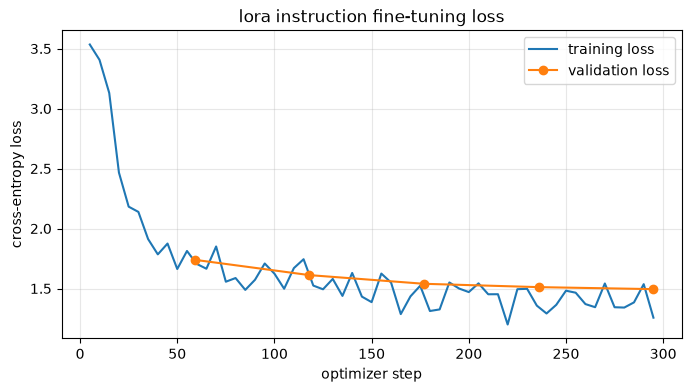

In [22]:
# inspect the logged training and validation losses for signs of learning or overfitting

history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(8, 4))

if "loss" in history:
    training_history = history.dropna(subset=["loss"])
    plt.plot(training_history["step"], training_history["loss"], label="training loss")

if "eval_loss" in history:
    validation_history = history.dropna(subset=["eval_loss"])
    plt.plot(validation_history["step"], validation_history["eval_loss"], marker="o", label="validation loss")

plt.xlabel("optimizer step")
plt.ylabel("cross-entropy loss")
plt.title("lora instruction fine-tuning loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [23]:
# evaluate once on validation data and once on untouched test data

validation_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["validation"],
    metric_key_prefix="validation",
)

test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)

print("validation loss:", validation_metrics["validation_loss"])
print("validation perplexity:", math.exp(validation_metrics["validation_loss"]))
print("test loss:", test_metrics["test_loss"])
print("test perplexity:", math.exp(test_metrics["test_loss"]))

Training Loss,Validation Loss,Epoch
1.256727,1.494714,5


Training Loss,Validation Loss,Epoch
1.256727,1.279596,5


validation loss: 1.494713544845581
validation perplexity: 4.458059335848404
test loss: 1.279595971107483
test perplexity: 3.5951868727212037


In [24]:
# define greedy decoding with no key-value cache for MPS-friendly inference

def generate_greedy(model, encoded_prompt, max_new_tokens, eos_token_id):
    input_ids = encoded_prompt["input_ids"]
    attention_mask = encoded_prompt.get("attention_mask")

    model.eval()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=False,
            )

            next_token_id = torch.argmax(
                outputs.logits[:, -1, :],
                dim=-1,
                keepdim=True,
            )

            input_ids = torch.cat((input_ids, next_token_id), dim=1)

            if attention_mask is not None:
                attention_mask = torch.cat(
                    (attention_mask, torch.ones_like(next_token_id)),
                    dim=1,
                )

            if eos_token_id is not None and (next_token_id == eos_token_id).all():
                break

    return input_ids


def generate_response(model, example):
    prompt = format_prompt(example)

    encoded_prompt = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )

    encoded_prompt = {
        name: tensor.to(device)
        for name, tensor in encoded_prompt.items()
    }

    prompt_length = encoded_prompt["input_ids"].shape[1]
    generated_ids = generate_greedy(
        model=model,
        encoded_prompt=encoded_prompt,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
    )

    response_token_ids = generated_ids[0, prompt_length:]

    return tokenizer.decode(response_token_ids, skip_special_tokens=True).strip()

In [25]:
# inspect a few held-out generations qualitatively before trusting a single metric

evaluation_rows = []

for example_index in range(3):
    example = dataset["test"][example_index]
    prediction = generate_response(model, example)

    evaluation_rows.append(
        {
            "example_index": example_index,
            "instruction": example["instruction"],
            "input": example["input"],
            "reference": example["output"],
            "lora_response": prediction,
        }
    )

    if device.type == "mps":
        torch.mps.empty_cache()

evaluation_results = pd.DataFrame(evaluation_rows)
evaluation_results

,example_index,instruction,input,reference,lora_response
0,0,Name three essential vitamins for human health.,,1. Vitamin A\n2. Vitamin C\n3. Vitamin D,1. Vitamin A\n2. Vitamin C\n3. Vitamin E
1,1,Rewrite the following sentence to include a pe...,The wind is very strong today.,"The wind howls with might today, as if declari...",The wind is strong today.
2,2,Rewrite the sentence using a simile.,She is very graceful.,She is as graceful as a swan.,She is very graceful.


In [26]:
# save the small adapter, tokenizer, and a plain-text experiment record

adapter_folder.mkdir(parents=True, exist_ok=True)
model.save_pretrained(adapter_folder)
tokenizer.save_pretrained(adapter_folder)

experiment_record = {
    "base_model": model_name,
    "seed": seed,
    "max_length": max_length,
    "lora_rank": lora_rank,
    "lora_alpha": lora_alpha,
    "lora_dropout": lora_dropout,
    "learning_rate": learning_rate,
    "num_train_epochs": num_train_epochs,
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
}

with (adapter_folder / "experiment_record.json").open("w", encoding="utf-8") as file:
    json.dump(experiment_record, file, indent=2)

print("saved adapter files:")
print(*sorted(path.name for path in adapter_folder.iterdir()), sep="\n")

saved adapter files:
README.md
adapter_config.json
adapter_model.safetensors
experiment_record.json
tokenizer.json
tokenizer_config.json


In [27]:
# release the training model before loading a fresh base-model copy

del trainer
del model

if device.type == "mps":
    torch.mps.empty_cache()

# load the unchanged base model and attach the adapter saved above

reloaded_base_model = AutoModelForCausalLM.from_pretrained(model_name)
reloaded_base_model.config.pad_token_id = tokenizer.pad_token_id

reloaded_model = PeftModel.from_pretrained(
    reloaded_base_model,
    adapter_folder,
).to(device)
reloaded_model.eval()

print("reloaded model type:", type(reloaded_model).__name__)
print("adapter config exists:", (adapter_folder / "adapter_config.json").exists())

# pass reloaded_model to generate_response when you want another inference check

print(generate_response(reloaded_model, dataset["test"][0]))

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10301.82it/s]


reloaded model type: PeftModelForCausalLM
adapter config exists: True
1. Vitamin A
2. Vitamin C
3. Vitamin E
